In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.image as mpimg
from tensorflow.keras.utils import plot_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

###  Load Dataset

In [3]:
df = pd.read_csv("/content/mushrooms.csv")

### Check the shape (number of rows and columns)

In [4]:
print("shape data :",df.shape)

shape data : (8124, 23)


In [5]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Check for missing values

In [6]:
print(df.isnull().sum())
# No missing values were found,
# so no filling or dropping was needed.

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


### Check class balance

class
e    4208
p    3916
Name: count, dtype: int64


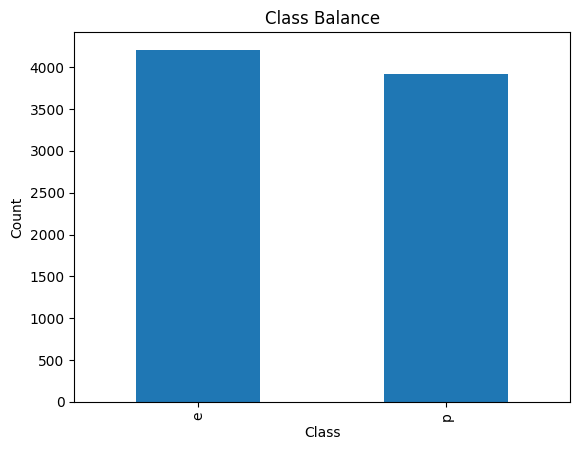

In [7]:
print(df['class'].value_counts())
df['class'].value_counts().plot(kind='bar')
plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#### Yes, there are roughly equal numbers of each label, so the dataset is balanced.

#### e = edible
#### p = poisonous

#### This means there is no significant class imbalance issue.

## Task 1.2 — Prepare the Data

In [8]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6499, 22)
(1625, 22)


## Task 1.3 — Train and Compare Models

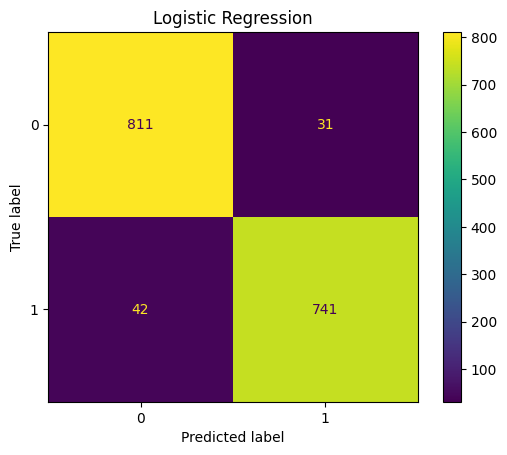

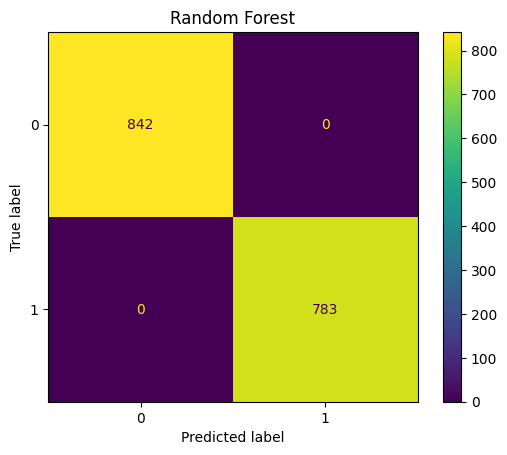

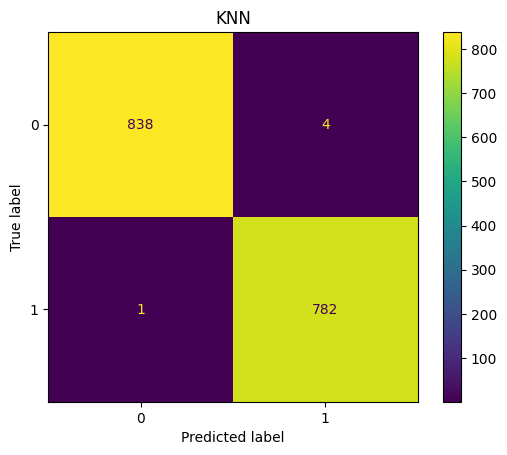

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.955077   0.959845  0.946360  0.953055
1        Random Forest  1.000000   1.000000  1.000000  1.000000
2                  KNN  0.996923   0.994911  0.998723  0.996813


In [9]:
encoder = LabelEncoder()

for col in X_train.columns:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score"
])
print(results_df)

### **Best Model : Randome forest**
##### Random Forest : 100%
##### Logistic Regression : 95.7%
##### KNN : 99.7%

# Step 2: Neural Network

## Task 2.1 — Build and Train

In [10]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7743 - loss: 0.5104 - val_accuracy: 0.9077 - val_loss: 0.2515
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.2504 - val_accuracy: 0.9366 - val_loss: 0.1463
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9383 - loss: 0.1573 - val_accuracy: 0.9557 - val_loss: 0.0982
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9578 - loss: 0.1100 - val_accuracy: 0.9778 - val_loss: 0.0701
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9657 - loss: 0.0938 - val_accuracy: 0.9834 - val_loss: 0.0485
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9737 - loss: 0.0724 - val_accuracy: 0.9902 - val_loss: 0.0325
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9794 - loss: 0.0622 - val_accuracy: 0.9914 - val_loss: 0.0292
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9842 - loss: 0.0457 - val_accuracy: 0.

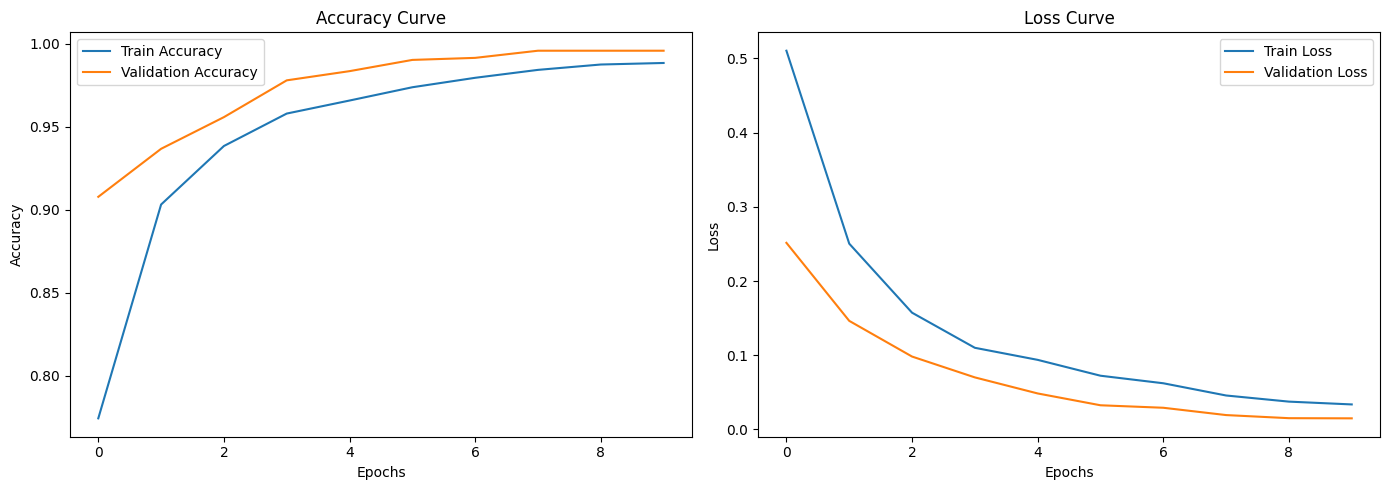

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

## Task 2.2 — Compare with Step 1

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


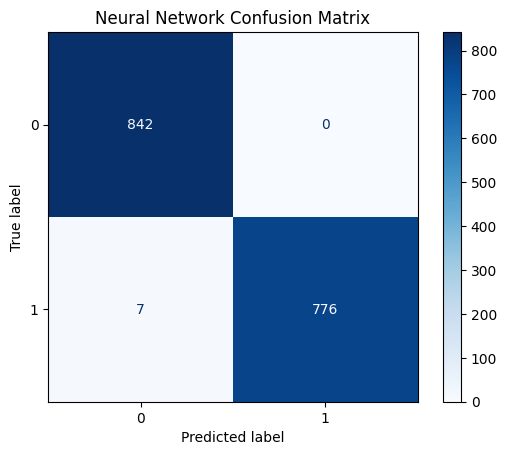

In [14]:
nn_loss, nn_acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_nn = model.predict(X_test)
y_pred_nn = (y_pred_nn > 0.5).astype(int)
nn_prec = precision_score(y_test, y_pred_nn)
nn_rec = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Neural Network Confusion Matrix")
plt.show()

In [15]:
nn_row = pd.DataFrame([[
    "Neural Network",
    nn_acc,
    nn_prec,
    nn_rec,
    nn_f1
]], columns=results_df.columns)
results_df = pd.concat([results_df, nn_row], ignore_index=True)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.955077   0.959845  0.946360  0.953055
1        Random Forest  1.000000   1.000000  1.000000  1.000000
2                  KNN  0.996923   0.994911  0.998723  0.996813
3       Neural Network  0.995692   1.000000  0.991060  0.995510


In [16]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


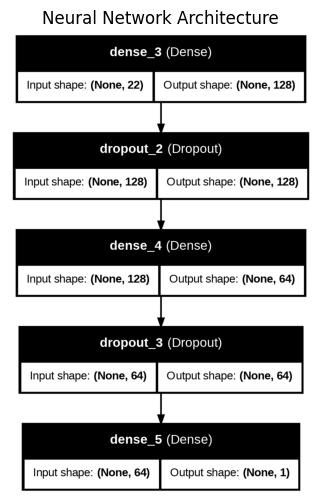

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    to_file='model_architecture.png'
)
img = mpimg.imread('model_architecture.png')
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off')
plt.title("Neural Network Architecture")
plt.show()

In [27]:
!pip install gradio pandas scikit-learn
import pandas as pd
import gradio as gr
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv("/content/mushrooms.csv")
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
X = df.drop("class", axis=1)
y = df["class"]
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)
nice = {
    "cap-shape": {
        "b": "Bell",
        "c": "Conical",
        "x": "Convex",
        "f": "Flat",
        "k": "Knobbed",
        "s": "Sunken"
    },
    "cap-surface": {
        "f": "Fibrous",
        "g": "Grooves",
        "y": "Scaly",
        "s": "Smooth"
    },
    "cap-color": {
        "n": "Brown",
        "b": "Buff",
        "c": "Cinnamon",
        "g": "Gray",
        "r": "Green",
        "p": "Pink",
        "u": "Purple",
        "e": "Red",
        "w": "White",
        "y": "Yellow"
    },
    "bruises": {
        "t": "Bruises",
        "f": "No Bruises"
    },
    "odor": {
        "a": "Almond",
        "l": "Anise",
        "c": "Creosote",
        "y": "Fishy",
        "f": "Foul",
        "m": "Musty",
        "n": "None",
        "p": "Pungent",
        "s": "Spicy"}}
reverse = {
    col: {v: k for k, v in nice[col].items()}
    for col in nice
}
def predict(cap_shape, cap_surface, cap_color, bruises, odor):
    inputs = [cap_shape, cap_surface, cap_color, bruises, odor]
    selected_cols = ["cap-shape", "cap-surface", "cap-color", "bruises", "odor"]
    full_input = []
    for i, col in enumerate(X.columns):
        if col in selected_cols:
            user_value = inputs[selected_cols.index(col)]
            raw_value = reverse[col][user_value]
        else:
            raw_value = encoders[col].classes_[0]
        full_input.append(encoders[col].transform([raw_value])[0])
    pred = model.predict([full_input])[0]
    result = encoders["class"].inverse_transform([pred])[0]
    if result == "e":
        return "🟢 SAFE TO EAT"
    else:
        return "🔴 POISONOUS"
with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as app:
    gr.Markdown("""
    # 🍄 Mushroom Intelligence System
    ### AI-powered edible vs poisonous classification
    """)
    with gr.Row():
        with gr.Column(scale=1):
            cap_shape = gr.Dropdown(
                choices=list(nice["cap-shape"].values()),
                label="Cap Shape")
            cap_surface = gr.Dropdown(
                choices=list(nice["cap-surface"].values()),
                label="Cap Surface" )
            cap_color = gr.Dropdown(
                choices=list(nice["cap-color"].values()),
                label="Cap Color")
            bruises = gr.Dropdown(
                choices=list(nice["bruises"].values()),
                label="Bruises")
            odor = gr.Dropdown(
                choices=list(nice["odor"].values()),
                label="Odor")
            btn = gr.Button("🔍 Predict Now", variant="primary")
        with gr.Column(scale=1):
            output = gr.Textbox(
                label="Result",
                interactive=False)
    btn.click(
        fn=predict,
        inputs=[cap_shape, cap_surface, cap_color, bruises, odor],
        outputs=output
    )

    gr.Markdown("⚡ Built with Machine Learning + Random Forest + Gradio UI")

app.launch()

/tmp/ipykernel_515/2596743898.py:78: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3fc88e3c64583cc37e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
